In [10]:
# Cell 1 — definitions only

import os, glob
import torch
import torch.nn.functional as F
from torch.utils.data import ConcatDataset
import pandas as pd
import numpy as np
from pyquaternion import Quaternion


class BEVSpec:
    """
    Defines the canonical BEV grid for fusion.
    """
    def __init__(self, x_min=0.0, x_max=50.0, cell_x=0.4, y_min=-25.0, y_max=25.0, cell_y=0.25):
        self.x_min = x_min
        self.x_max = x_max
        self.cell_x = cell_x
        
        self.y_min = y_min
        self.y_max = y_max
        self.cell_y = cell_y

    @property
    def H(self):
        return int(np.ceil((self.x_max - self.x_min) / self.cell_x))

    @property
    def W(self):
        return int(np.ceil((self.y_max - self.y_min) / self.cell_y))


class CameraCalib:
    def __init__(self, K, R, T):
        self.K = K
        self.R = R
        self.T = T

def extract_calibration_from_row(row: pd.Series) -> CameraCalib:
    K = np.array(row["cam_intrinsic"].split(';'), dtype=np.float64).reshape(3, 3)
    R = Quaternion([float(x) for x in row["sensor2ego_rotation"].split(';')]).rotation_matrix
    T = np.array(row["sensor2ego_translation"].split(';'), dtype=np.float64)
    return CameraCalib(K=K, R=R, T=T)


def get_matched_tokens(camera_feat_root, lidar_root, fpn_level):
    cam_files = glob.glob(os.path.join(camera_feat_root, f"*lvl{fpn_level}.pt"))
    lidar_files = glob.glob(os.path.join(lidar_root, "*.pt"))
    cam_tokens = {os.path.basename(f).replace(f"_lvl{fpn_level}.pt", ""): f for f in cam_files}
    lidar_tokens = {os.path.splitext(os.path.basename(f))[0]: f for f in lidar_files}
    matched = sorted(set(cam_tokens.keys()) & set(lidar_tokens.keys()))
    return matched


class TorchCameraBEVDataset:
    """
    Loads and projects FPN camera features into BEV grid using dynamic stride.
    """
    def __init__(self, sample_tokens, metadata_df: pd.DataFrame, camera_feat_root: str,
                 camera_name: str, fpn_level: int, bev_spec: BEVSpec):
        self.sample_tokens = sample_tokens
        self.metadata_df = metadata_df
        self.camera_feat_root = camera_feat_root
        self.camera_name = camera_name
        self.fpn_level = fpn_level
        self.bev_spec = bev_spec

    def __len__(self):
        return len(self.sample_tokens)

    def _load_camera_feat(self, token: str):
        feat_filename = f"{token}_lvl{self.fpn_level}.pt"
        feat_path = os.path.join(self.camera_feat_root, feat_filename)
        blob = torch.load(feat_path, map_location="cpu")
        cam_feat = blob["feat"]
        if cam_feat.ndim == 3:
            cam_feat = cam_feat.unsqueeze(0)
        # Get true image shape (for stride calculation)
        if 'img_shape' in blob:
            H_img, W_img, _ = blob['img_shape'][0]
        else:
            # fallback: take from metadata (or constants)
            H_img = int(self.metadata_df.query(
                f"sample_token == '{token}' and camera_name == '{self.camera_name}'"
            ).iloc[0].get('img_height', 928))
            W_img = int(self.metadata_df.query(
                f"sample_token == '{token}' and camera_name == '{self.camera_name}'"
            ).iloc[0].get('img_width', 1600))
        Hf, Wf = cam_feat.shape[-2], cam_feat.shape[-1]
        stride_u = W_img / Wf
        stride_v = H_img / Hf
        assert abs(stride_u - stride_v) < 1e-2, f"Stride asymmetric: {stride_u} vs {stride_v}"
        self._stride = stride_u
        self._img_shape = (H_img, W_img)
        return cam_feat

    def _lookup_calib(self, token: str):
        row = self.metadata_df.query(f"sample_token == '{token}' and camera_name == '{self.camera_name}'").iloc[0]
        return extract_calibration_from_row(row)

    def __getitem__(self, idx):
        token = self.sample_tokens[idx]
        cam_feat = self._load_camera_feat(token)  # [1,C,Hf,Wf]
        B, C, Hf, Wf = cam_feat.shape
        stride = self._stride

        calib = self._lookup_calib(token)
        # Compute pixel centers (dynamic stride)
        i = torch.arange(Hf, dtype=torch.float32) + 0.5
        j = torch.arange(Wf, dtype=torch.float32) + 0.5
        V, U = torch.meshgrid(i * stride, j * stride, indexing='ij')
        uv1 = np.stack([U.reshape(-1).numpy(), V.reshape(-1).numpy(), np.ones(Hf * Wf)], axis=0)
        K_inv = np.linalg.inv(calib.K)
        rays_cam = K_inv @ uv1
        rays_cam[1, :] *= -1.0
        rays_ego = calib.R @ rays_cam
        dir_z = rays_ego[2, :]
        cam_z = calib.T[2]
        s_ground = -cam_z / (dir_z + 1e-12)
        Xg = calib.T[0] + s_ground * rays_ego[0, :]
        Yg = calib.T[1] + s_ground * rays_ego[1, :]
        ix = ((Xg - self.bev_spec.x_min) / self.bev_spec.cell_x).astype(np.int64)
        iy = ((Yg - self.bev_spec.y_min) / self.bev_spec.cell_y).astype(np.int64)
        valid = (ix >= 0) & (ix < self.bev_spec.H) & (iy >= 0) & (iy < self.bev_spec.W) & (s_ground > 0)

        bev_grid = torch.zeros((B, C, self.bev_spec.H, self.bev_spec.W), dtype=cam_feat.dtype)
        cam_feat_flat = cam_feat.reshape(B, C, -1)
        valid_idx = np.flatnonzero(valid)
        ix_valid = torch.from_numpy(ix[valid]).long()
        iy_valid = torch.from_numpy(iy[valid]).long()
        cam_feat_valid = cam_feat_flat[:, :, valid_idx]
        for b in range(B):
            bev_flat = bev_grid[b].reshape(C, -1)
            linear_idx = ix_valid * self.bev_spec.W + iy_valid
            bev_flat.scatter_add_(1, linear_idx.unsqueeze(0).expand(C, -1), cam_feat_valid[b])
            bev_grid[b] = bev_flat.reshape(C, self.bev_spec.H, self.bev_spec.W)
        
        return {
            "cam_bev": bev_grid.squeeze(0),
            "image_id": token,
        }



    def collater(self, samples):
        samples = [s for s in samples if s is not None]
        if len(samples) == 0:
            return {}
        cam_bev_batch = torch.stack([s["cam_bev"] for s in samples])
        image_ids = [s["image_id"] for s in samples]
        return {
            "cam_bev": cam_bev_batch,
            "image_id": image_ids,
        }


class TorchLidarBEVDataset:
    """
    Loads Lidar BEV features and resamples to the canonical BEV grid.
    """
    def __init__(self, sample_tokens, lidar_root: str, pc_range, bev_spec: BEVSpec):
        self.sample_tokens = sample_tokens
        self.lidar_root = lidar_root
        self.pc_range = pc_range
        self.bev_spec = bev_spec

    def __len__(self):
        return len(self.sample_tokens)

    def _load_lidar_feat(self, token: str):
        feat_path = os.path.join(self.lidar_root, f"{token}.pt")
        blob = torch.load(feat_path, map_location="cpu")
        lidar_feat = blob["feat"]
        if lidar_feat.ndim == 3:
            lidar_feat = lidar_feat.unsqueeze(0)
        return lidar_feat

    def __getitem__(self, idx):
        token = self.sample_tokens[idx]
        lidar_feat = self._load_lidar_feat(token)
        # Resample to canonical BEV
        x_min_l, y_min_l, _, x_max_l, y_max_l, _ = self.pc_range
        H_cam = self.bev_spec.H
        W_cam = self.bev_spec.W
        cell_x = (self.bev_spec.x_max - self.bev_spec.x_min) / H_cam
        cell_y = (self.bev_spec.y_max - self.bev_spec.y_min) / W_cam
        xs = self.bev_spec.x_min + (torch.arange(H_cam, dtype=torch.float32) + 0.5) * cell_x
        ys = self.bev_spec.y_min + (torch.arange(W_cam, dtype=torch.float32) + 0.5) * cell_y
        Xg, Yg = torch.meshgrid(xs, ys, indexing='ij')
        grid_x = 2.0 * (Yg - y_min_l) / (y_max_l - y_min_l) - 1.0
        grid_y = 2.0 * (Xg - x_min_l) / (x_max_l - x_min_l) - 1.0
        grid = torch.stack([grid_x, grid_y], dim=-1).unsqueeze(0)
        lidar_on_cam = F.grid_sample(
            lidar_feat,
            grid,
            mode='bilinear',
            padding_mode='zeros',
            align_corners=True
        )
        return {
            "lidar_bev": lidar_on_cam.squeeze(0),
            "image_id": token,
        }



class WrappedConcatBEVDataset(ConcatDataset):
    """
    Returns paired (camera, lidar) BEV tensors for each token.
    """
    def __init__(self, cam_dataset: TorchCameraBEVDataset, lidar_dataset: TorchLidarBEVDataset):
        assert len(cam_dataset) == len(lidar_dataset), "Camera and Lidar token sets must align 1:1."
        super().__init__([cam_dataset, lidar_dataset])
        self.cam_dataset = cam_dataset
        self.lidar_dataset = lidar_dataset

    def __len__(self):
        return min(len(self.cam_dataset), len(self.lidar_dataset))

    def __getitem__(self, idx):
        cam_sample = self.cam_dataset[idx]
        lidar_sample = self.lidar_dataset[idx]
        if cam_sample is None or lidar_sample is None:
            return None
        if cam_sample["image_id"] != lidar_sample["image_id"]:
            return None
        return {
            "cam_bev": cam_sample["cam_bev"],
            "lidar_bev": lidar_sample["lidar_bev"],
            "image_id": cam_sample["image_id"],
            "label": 1,
        }

    def collater(self, samples):
        samples = [s for s in samples if s is not None]
        if len(samples) == 0:
            return {}
        cam_bev_batch = torch.stack([s["cam_bev"] for s in samples])
        lidar_bev_batch = torch.stack([s["lidar_bev"] for s in samples])
        image_ids = [s["image_id"] for s in samples]
        labels = torch.tensor([s["label"] for s in samples])
        return {
            "cam_bev": cam_bev_batch,
            "lidar_bev": lidar_bev_batch,
            "image_id": image_ids,
            "label": labels,
        }


class NuScenesDatasetBuilder:
    """
    Builds train/val/test datasets aligned to BEV tensors.
    """
    def __init__(self, cfg):
        self.cfg = cfg

    def build_datasets(self):
        build_info = self.cfg.datasets_cfg["nuscenes"].build_info
        datasets = {}
        bev_cfg = build_info["bev"]
        cam_proj = build_info["cam_proj"]
        lidar_proj = build_info["lidar_proj"]
        bev_spec = BEVSpec(
            x_min=bev_cfg.x_min,
            x_max=bev_cfg.x_max,
            cell_x=bev_cfg.cell_x,
            y_min=bev_cfg.y_min,
            y_max=bev_cfg.y_max,
            cell_y=bev_cfg.cell_y,
        )
        for split in ["train", "val", "test"]:
            if split not in (self.cfg.run_cfg.train_splits
                            + self.cfg.run_cfg.valid_splits
                            + self.cfg.run_cfg.test_splits):
                continue
            camera_root = build_info["camera"][split].storage
            lidar_root = build_info["lidar"][split].storage
            metadata_csv_key = f"metadata_csv_{split}"
            if metadata_csv_key in build_info:
                metadata_csv_path = build_info[metadata_csv_key]
            else:
                metadata_csv_path = build_info["metadata_csv"]
            metadata_df = pd.read_csv(metadata_csv_path)
            tokens = get_matched_tokens(
                camera_feat_root=camera_root,
                lidar_root=lidar_root,
                fpn_level=cam_proj.fpn_level,
            )
            cam_ds = TorchCameraBEVDataset(
                sample_tokens=tokens,
                metadata_df=metadata_df,
                camera_feat_root=camera_root,
                camera_name=cam_proj.camera_name,
                fpn_level=cam_proj.fpn_level,
                bev_spec=bev_spec,
            )
            lidar_ds = TorchLidarBEVDataset(
                sample_tokens=tokens,
                lidar_root=lidar_root,
                pc_range=lidar_proj.pc_range,
                bev_spec=bev_spec,
            )
            datasets[split] = WrappedConcatBEVDataset(cam_ds, lidar_ds)
        return datasets




In [ ]:
# Cell 2 — visualization helper
import matplotlib.pyplot as plt
%matplotlib inline

def visualize_sample(sample, title=""):
    cam = sample["cam_bev"].cpu().numpy()
    lidar = sample["lidar_bev"].cpu().numpy()
    
    # Choose 1 channel to view (0 or mean)
    cam_vis = cam.mean(axis=0)
    lidar_vis = lidar.mean(axis=0)

    plt.figure(figsize=(14,5))
    plt.suptitle(title, fontsize=14)

    plt.subplot(1,2,1)
    plt.title("Camera BEV")
    plt.imshow(cam_vis, cmap="viridis")
    plt.colorbar()

    plt.subplot(1,2,2)
    plt.title("LiDAR BEV")
    plt.imshow(lidar_vis, cmap="magma")
    plt.colorbar()

    plt.show()


In [61]:
# Cell 3 — main logic in Jupyter form

camera_dir = "/home/draiman/Desktop/Datasets_nuscenes/validation/fpn/CAM_FRONT"
lidar_dir   = "/home/draiman/Desktop/Datasets_nuscenes/validation/lidar"
metadata_csv = "/home/draiman/Desktop/Datasets_nuscenes/nuscenes_metadata.csv"

camera_name = "CAM_FRONT"
fpn_level = 0
pc_range = [-54, -54, -5, 54, 54, 3]

bev_spec = BEVSpec(
    x_min=0.0, x_max=50.0, cell_x=0.4,
    y_min=-25.0, y_max=25.0, cell_y=0.25,
)

tokens = get_matched_tokens(camera_dir, lidar_dir, fpn_level)
print("Matched tokens:", len(tokens))

metadata_df = pd.read_csv(metadata_csv)
print("Loaded metadata:", len(metadata_df))
print("BEV grid:", bev_spec.H, "x", bev_spec.W)

cam_ds = TorchCameraBEVDataset(
    sample_tokens=tokens,
    metadata_df=metadata_df,
    camera_feat_root=camera_dir,
    camera_name=camera_name,
    fpn_level=fpn_level,
    bev_spec=bev_spec,
)

lidar_ds = TorchLidarBEVDataset(
    sample_tokens=tokens,
    lidar_root=lidar_dir,
    pc_range=pc_range,
    bev_spec=bev_spec,
)

dataset = WrappedConcatBEVDataset(cam_ds, lidar_ds)


Matched tokens: 1982
Loaded metadata: 11892
BEV grid: 125 x 200



Sample 0
Camera BEV: torch.Size([256, 125, 200])
LiDAR BEV: torch.Size([256, 125, 200])
Token: 000681a060c04755a1537cf83b53ba57
1) camera feature filled cells = 2402


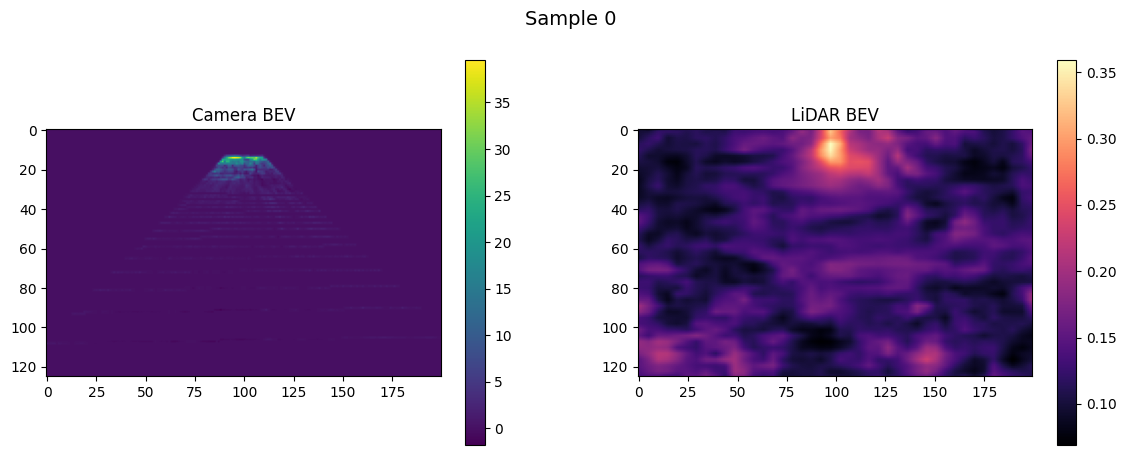


Sample 1
Camera BEV: torch.Size([256, 125, 200])
LiDAR BEV: torch.Size([256, 125, 200])
Token: 000868a72138448191b4092f75ed7776
1) camera feature filled cells = 2458


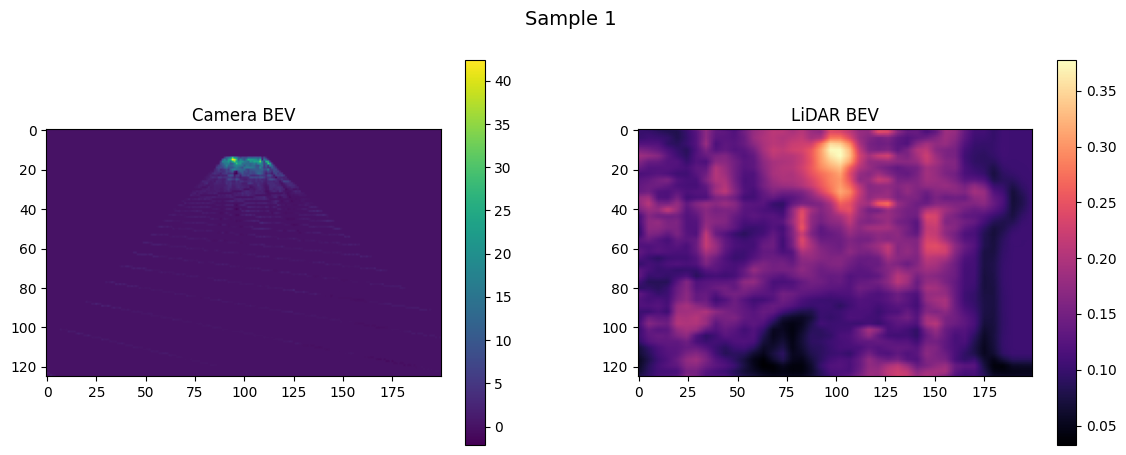


Sample 2
Camera BEV: torch.Size([256, 125, 200])
LiDAR BEV: torch.Size([256, 125, 200])
Token: 005d3e821c4e4e0ab03f1ea1dcbf9cc8
1) camera feature filled cells = 2402


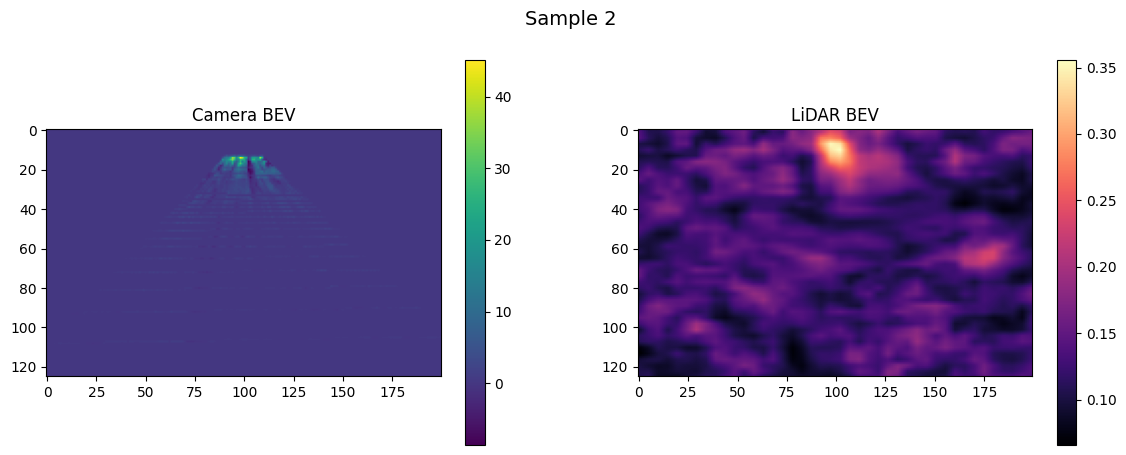

In [ ]:
# Cell 4 — Inspect first few samples

for i in range(min(3, len(dataset))):
    sample = dataset[i]
    print("\nSample", i)
    print("Camera BEV:", sample['cam_bev'].shape)
    print("LiDAR BEV:", sample['lidar_bev'].shape)
    print("Token:", sample['image_id'])

    visualize_sample(sample, title=f"Sample {i}")

In [63]:
sample = dataset[0]
cam = sample["cam_bev"].cpu().numpy()
lidar = sample["lidar_bev"].cpu().numpy()

# Choose 1 channel to view (0 or mean)
cam_vis = cam.mean(axis=0)
lidar_vis = lidar.mean(axis=0)

cam_vis_filled = int((cam_vis != 0).sum())
print(f"1) camera feature filled cells = {cam_vis_filled}")


1) camera feature filled cells = 2402


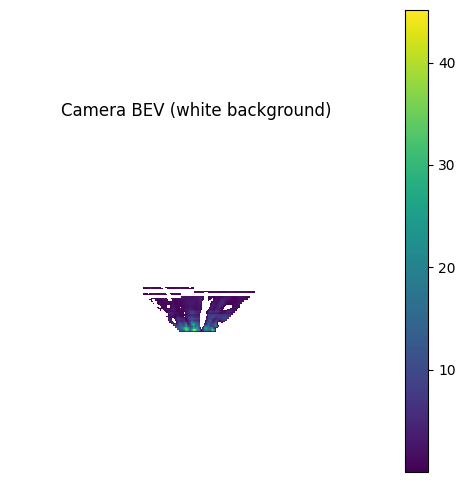

Debugging the outputs 

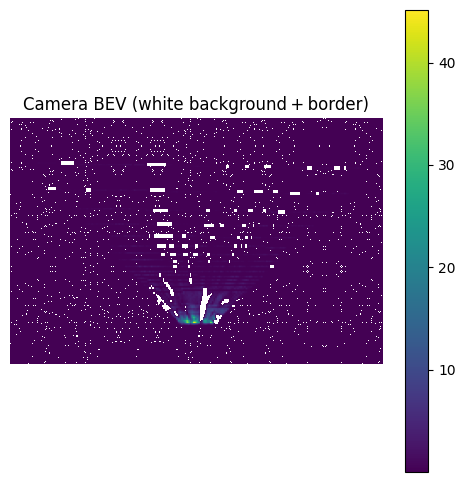

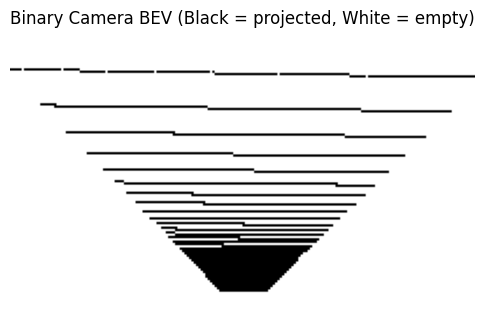

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# cam_bev is shape [C, H, W]
bev = sample["cam_bev"]

# Convert to numpy (C, H, W)
bev_np = bev.cpu().numpy()

# Create a binary mask:
# 1 = projected cell
# 0 = empty cell
mask = (bev_np.sum(axis=0) != 0).astype(np.uint8)

# Invert for white background:
# 0 → white (empty)
# 1 → black (projected)
mask_visual = 1 - mask

plt.figure(figsize=(6,6))
plt.title("Binary Camera BEV (Black = projected, White = empty)")
plt.imshow(mask_visual, cmap="gray", origin="lower", vmin=0, vmax=1)
plt.axis("off")
plt.show()


Original uniform BEV: (125, 200)


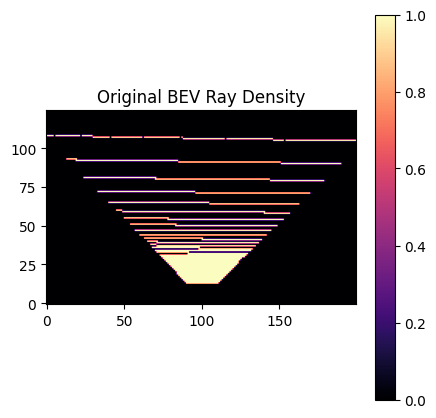

Dense region in X rows: (12, 110)
Adaptive BEV shape: (256, 105, 200)


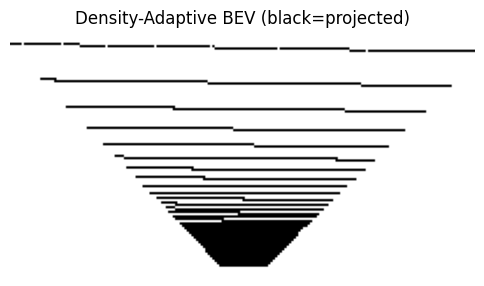

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# ------------------------------------------------------------
# 1) Load one camera BEV sample from your dataset
# ------------------------------------------------------------
sample_idx = 0        # change if you want a different token
sample = cam_ds[sample_idx]

feat = sample["cam_bev"]       # [C, H, W]
feat_np = feat.cpu().numpy()

H, W = feat_np.shape[1], feat_np.shape[2]
C = feat_np.shape[0]

print("Original uniform BEV:", (H, W))

# ------------------------------------------------------------
# 2) Compute per-cell density map = #nonzero channels
# ------------------------------------------------------------
density = (feat_np != 0).sum(axis=0)     # shape [H, W]

# normalize for plotting
density_norm = density / density.max()

plt.figure(figsize=(5,5))
plt.title("Original BEV Ray Density")
plt.imshow(density_norm, cmap='magma', origin='lower')
plt.colorbar()
plt.show()

# ------------------------------------------------------------
# 3) Create density-adaptive BEV grid edges
# ------------------------------------------------------------
# collapse along Y (axis=1) to get density by X (forward)
density_x = density.sum(axis=1)     # shape [H]

# smooth
from scipy.ndimage import gaussian_filter1d
density_x_smooth = gaussian_filter1d(density_x, sigma=3)

# threshold to find “dense region”
thr = 0.20 * density_x_smooth.max()           # 20% of peak
dense_mask = density_x_smooth > thr

# get dense interval along X
dense_indices = np.where(dense_mask)[0]
x_min_dense = dense_indices.min()
x_max_dense = dense_indices.max()

print("Dense region in X rows:", (x_min_dense, x_max_dense))

# ------------------------------------------------------------
# 4) Build custom BEV:
#    fine resolution in [x_min_dense:x_max_dense],
#    coarse resolution outside
# ------------------------------------------------------------
def adaptive_resample(feat_np, x_min, x_max, fine_factor=1, coarse_factor=4):
    C, H, W = feat_np.shape
    
    # fine region keeps original resolution
    fine = feat_np[:, x_min:x_max+1, :]           # [C, H_fine, W]
    
    # coarse front region (0:x_min)
    front = feat_np[:, :x_min, :]                 # [C, H_front, W]
    # downsample in X dimension
    front_ds = torch.nn.functional.interpolate(
        torch.tensor(front).unsqueeze(0),
        size=(front.shape[1] // coarse_factor, W),
        mode='bilinear',
        align_corners=True
    ).squeeze(0).numpy()
    
    # coarse back region (x_max:H)
    back = feat_np[:, x_max+1:, :]                # [C, H_back, W]
    back_ds = torch.nn.functional.interpolate(
        torch.tensor(back).unsqueeze(0),
        size=(max(1, back.shape[1] // coarse_factor), W),
        mode='bilinear',
        align_corners=True
    ).squeeze(0).numpy()
    
    # concatenate: front_ds → fine → back_ds
    out = np.concatenate([front_ds, fine, back_ds], axis=1)
    return out

adaptive_bev = adaptive_resample(
    feat_np,
    x_min_dense,
    x_max_dense,
    fine_factor=1,
    coarse_factor=4
)

print("Adaptive BEV shape:", adaptive_bev.shape)

# ------------------------------------------------------------
# 5) Visualize the adaptive BEV mask (white=empty, black=projected)
# ------------------------------------------------------------
binary_mask = (adaptive_bev.sum(axis=0) != 0).astype(np.uint8)
binary_vis = 1 - binary_mask   # invert for white background

plt.figure(figsize=(6,6))
plt.title("Density-Adaptive BEV (black=projected)")
plt.imshow(binary_vis, cmap='gray', origin='lower', vmin=0, vmax=1)
plt.axis('off')
plt.show()


Loaded BEV: torch.Size([256, 125, 200])
Polar BEV shape: (256, 80, 180)


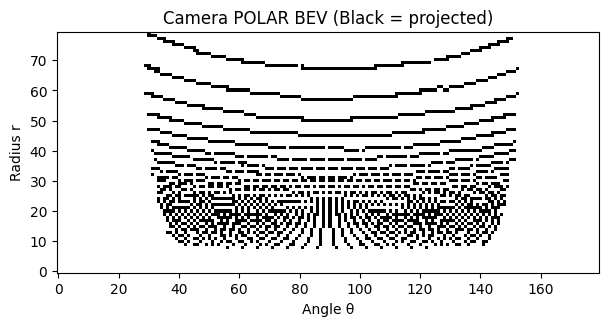

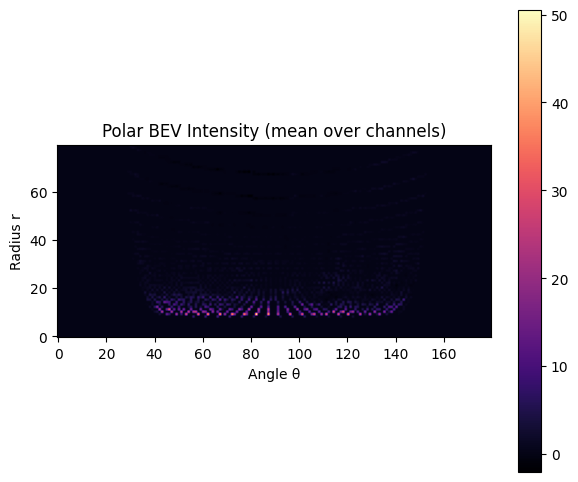

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# ======================================================
# 1) Load sample from your existing camera BEV dataset
# ======================================================
sample_idx = 0      # change token here
sample = cam_ds[sample_idx]     # cam_ds from your previous code

cam_bev = sample["cam_bev"]     # shape [C, H, W]
C, H_cam, W_cam = cam_bev.shape
print("Loaded BEV:", cam_bev.shape)

# ======================================================
# 2) Build POLAR GRID (θ × r)
# ======================================================
N_theta = 180      # number of angle bins   (1 degree steps)
N_r     = 80       # number of radial bins  (meters or BEV rows)

# θ spans full camera FOV (dependent on camera intrinsics)
# For now assume symmetric horizontal FOV = 90° (±45°)
theta_min = -45.0 * np.pi/180
theta_max =  45.0 * np.pi/180

# r spans from 0 to max range of BEV
r_min = 0.0
r_max = 50.0      # use your BEV x_max range

thetas = np.linspace(theta_min, theta_max, N_theta)
rs     = np.linspace(r_min, r_max, N_r)

# ======================================================
# 3) Map BEV Cartesian coordinates (x,y) → Polar (r, θ)
# ======================================================
# Prepare Cartesian BEV grid to map projection
# (This converts every BEV pixel center back into (x,y) in meters)

# These must match your original BEVSpec:
x_min, x_max = 0.0, 50.0
y_min, y_max = -25.0, 25.0

cell_x = (x_max - x_min) / H_cam
cell_y = (y_max - y_min) / W_cam

xs = x_min + (np.arange(H_cam) + 0.5) * cell_x
ys = y_min + (np.arange(W_cam) + 0.5) * cell_y
Xg, Yg = np.meshgrid(xs, ys, indexing='ij')

# Convert each BEV cell to polar coordinates:
R = np.sqrt(Xg**2 + Yg**2)
Theta = np.arctan2(Yg, Xg)

# ======================================================
# 4) Digitize each BEV cell into polar bins
# ======================================================
# Each BEV pixel belongs to 1 radial bin & 1 angular bin
r_idx = np.digitize(R, rs) - 1
t_idx = np.digitize(Theta, thetas) - 1

# Mask invalid (outside FOV or range)
valid = (r_idx>=0)&(r_idx<N_r)&(t_idx>=0)&(t_idx<N_theta)

# ======================================================
# 5) Initialize POLAR BEV tensor
# ======================================================
polar_bev = np.zeros((C, N_r, N_theta), dtype=np.float32)

# Flatten camera BEV for accumulation
cam_flat = cam_bev.cpu().numpy().reshape(C, -1)

# List of valid BEV cells
flat_idx = np.where(valid.reshape(-1))[0]
r_valid  = r_idx.reshape(-1)[flat_idx]
t_valid  = t_idx.reshape(-1)[flat_idx]

# ======================================================
# 6) Scatter-add camera features into polar grid
# ======================================================
for c in range(C):
    np.add.at(polar_bev[c], (r_valid, t_valid), cam_flat[c, flat_idx])

print("Polar BEV shape:", polar_bev.shape)  # [C, N_r, N_theta]

# ======================================================
# 7) Visualize POLAR BEV footprint (binary)
# ======================================================
binary_mask = (polar_bev.sum(axis=0) != 0).astype(np.uint8)
binary_vis = 1 - binary_mask   # white background, black projection

plt.figure(figsize=(7,6))
plt.title("Camera POLAR BEV (Black = projected)")
plt.imshow(binary_vis, cmap='gray', origin='lower')
plt.xlabel("Angle θ")
plt.ylabel("Radius r")
plt.show()

# ======================================================
# 8) Visualize POLAR BEV intensity map
# ======================================================
plt.figure(figsize=(7,6))
plt.title("Polar BEV Intensity (mean over channels)")
plt.imshow(polar_bev.mean(axis=0), cmap='magma', origin='lower')
plt.colorbar()
plt.xlabel("Angle θ")
plt.ylabel("Radius r")
plt.show()


Loaded LIDAR BEV: torch.Size([256, 125, 200])
Using existing polar grid: 80 radial bins, 180 angular bins
LIDAR Polar BEV shape: (256, 80, 180)


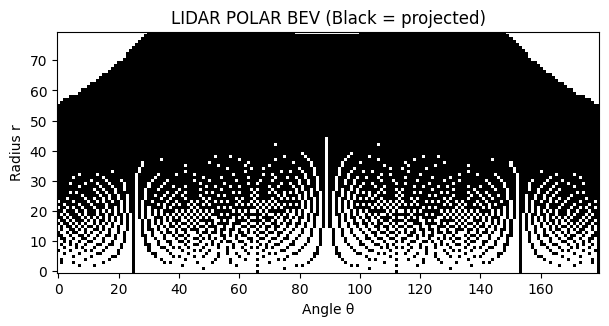

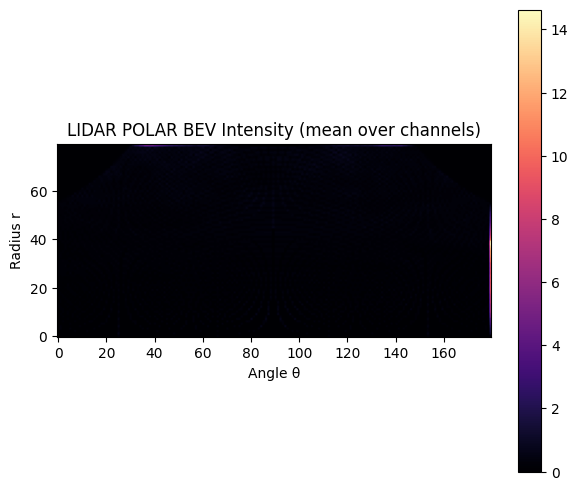

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# ======================================================
# 1) Load LIDAR sample from your existing LiDAR BEV dataset
# ======================================================
lidar_sample = lidar_ds[sample_idx]     # use same token index
lidar_bev = lidar_sample["lidar_bev"]   # shape [C_l, H_l, W_l]

C_l, H_l, W_l = lidar_bev.shape
print("Loaded LIDAR BEV:", lidar_bev.shape)

# ======================================================
# 2) Use the SAME polar grid created for the camera
# (thetas, rs, N_theta, N_r)
# ======================================================
print("Using existing polar grid:", N_r, "radial bins,", N_theta, "angular bins")

# ======================================================
# 3) Compute LiDAR BEV grid -> (x,y) coordinates
# ======================================================
x_min_L, x_max_L = 0.0, 50.0
y_min_L, y_max_L = -25.0, 25.0

cell_x_L = (x_max_L - x_min_L) / H_l
cell_y_L = (y_max_L - y_min_L) / W_l

xs_L = x_min_L + (np.arange(H_l) + 0.5) * cell_x_L
ys_L = y_min_L + (np.arange(W_l) + 0.5) * cell_y_L
Xg_L, Yg_L = np.meshgrid(xs_L, ys_L, indexing='ij')

# ======================================================
# 4) Convert to polar coordinates (r, θ)
# ======================================================
R_L = np.sqrt(Xg_L**2 + Yg_L**2)
Theta_L = np.arctan2(Yg_L, Xg_L)

# bin assignments
r_idx_L = np.digitize(R_L, rs) - 1
t_idx_L = np.digitize(Theta_L, thetas) - 1

# valid mask
valid_L = (r_idx_L>=0)&(r_idx_L<N_r)&(t_idx_L>=0)&(t_idx_L<N_theta)

# ======================================================
# 5) Initialize POLAR BEV for LiDAR
# ======================================================
polar_lidar = np.zeros((C_l, N_r, N_theta), dtype=np.float32)

# flatten lidar BEV for accumulation
lidar_flat = lidar_bev.cpu().numpy().reshape(C_l, -1)

# valid BEV pixels
flat_idx_L = np.where(valid_L.reshape(-1))[0]
r_valid_L  = r_idx_L.reshape(-1)[flat_idx_L]
t_valid_L  = t_idx_L.reshape(-1)[flat_idx_L]

# scatter into polar grid
for c in range(C_l):
    np.add.at(polar_lidar[c], (r_valid_L, t_valid_L), lidar_flat[c, flat_idx_L])

print("LIDAR Polar BEV shape:", polar_lidar.shape)

# ======================================================
# 6) Visualize Polar LIDAR BEV (binary mask)
# ======================================================
binary_mask_L = (polar_lidar.sum(axis=0) != 0).astype(np.uint8)
binary_vis_L  = 1 - binary_mask_L

plt.figure(figsize=(7,6))
plt.title("LIDAR POLAR BEV (Black = projected)")
plt.imshow(binary_vis_L, cmap="gray", origin="lower")
plt.xlabel("Angle θ")
plt.ylabel("Radius r")
plt.show()

# ======================================================
# 7) Visualize Polar LIDAR intensity
# ======================================================
plt.figure(figsize=(7,6))
plt.title("LIDAR POLAR BEV Intensity (mean over channels)")
plt.imshow(polar_lidar.mean(axis=0), cmap="magma", origin="lower")
plt.colorbar()
plt.xlabel("Angle θ")
plt.ylabel("Radius r")
plt.show()


LiDAR BEV shape: torch.Size([256, 125, 200])


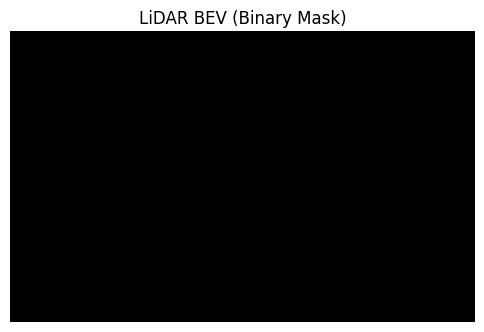

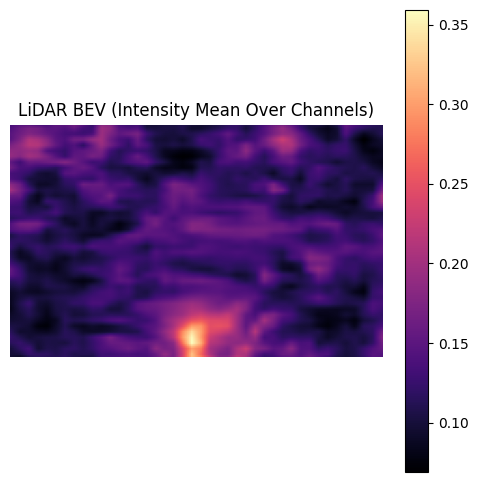

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Load LiDAR sample (you already have lidar_ds)
sample_idx = 0  # choose sample
lidar_sample = lidar_ds[sample_idx]

lidar_bev = lidar_sample["lidar_bev"]  # [C, H, W]
C_l, H_l, W_l = lidar_bev.shape

print("LiDAR BEV shape:", lidar_bev.shape)

# ==========================
# 1) BINARY OCCUPANCY MASK
# ==========================
binary_mask = (lidar_bev.sum(axis=0).cpu().numpy() != 0).astype(np.uint8)
binary_vis = 1 - binary_mask   # white background

plt.figure(figsize=(6,6))
plt.title("LiDAR BEV (Binary Mask)")
plt.imshow(binary_vis, cmap='gray', origin='lower', vmin=0, vmax=1)
plt.axis('off')
plt.show()

# ==========================
# 2) INTENSITY HEATMAP
# ==========================
lidar_intensity = lidar_bev.mean(axis=0).cpu().numpy()

plt.figure(figsize=(6,6))
plt.title("LiDAR BEV (Intensity Mean Over Channels)")
plt.imshow(lidar_intensity, cmap='magma', origin='lower')
plt.colorbar()
plt.axis('off')
plt.show()


LiDAR raw BEV shape: torch.Size([256, 90, 90])


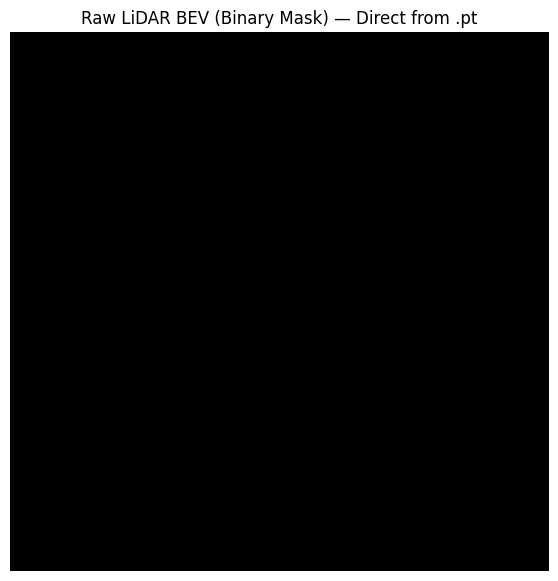

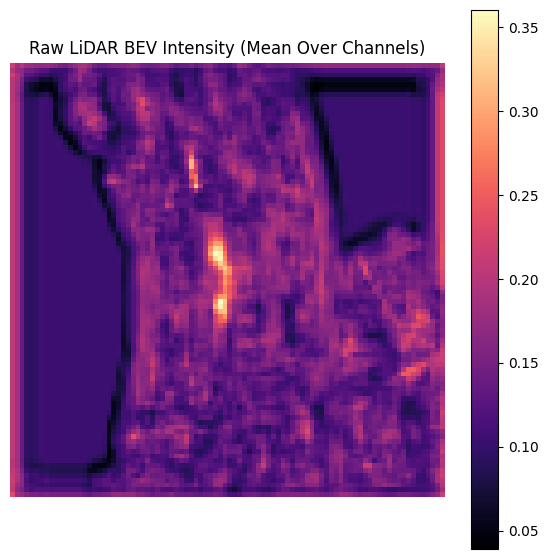

In [24]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------------------------------------
# 1) Load raw LiDAR BEV .pt file (no modifications)
# ----------------------------------------------------------
PT_PATH = "/home/draiman/Desktop/Datasets_nuscenes/validation/lidar/01a7d01c014f406f87b8fe11976c3d0a.pt"

blob = torch.load(PT_PATH, map_location="cpu")

# raw tensor straight from .pt
lidar_bev = blob["feat"]   # shape [C, H, W]
lidar_bev = lidar_bev.squeeze(0) if lidar_bev.ndim == 4 else lidar_bev

print("LiDAR raw BEV shape:", lidar_bev.shape)

# ----------------------------------------------------------
# 2) SIMPLE binary occupancy visualization
# ----------------------------------------------------------
binary_mask = (lidar_bev.sum(dim=0).numpy() != 0).astype(np.uint8)
binary_vis = 1 - binary_mask  # white background

plt.figure(figsize=(7,7))
plt.title("Raw LiDAR BEV (Binary Mask) — Direct from .pt")
plt.imshow(binary_vis, cmap="gray", origin="lower", vmin=0, vmax=1)
plt.axis("off")
plt.show()

# ----------------------------------------------------------
# 3) Simple intensity heatmap (mean across channels)
# ----------------------------------------------------------
lidar_intensity = lidar_bev.mean(dim=0).numpy()

plt.figure(figsize=(7,7))
plt.title("Raw LiDAR BEV Intensity (Mean Over Channels)")
plt.imshow(lidar_intensity, cmap="magma", origin="lower")
plt.colorbar()
plt.axis("off")
plt.show()


LiDAR BEV shape: torch.Size([256, 90, 90])
Cropped LiDAR BEV shape: torch.Size([256, 1, 44])


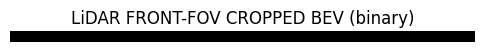

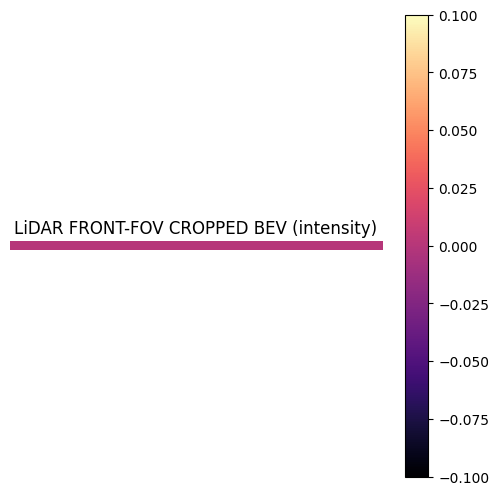

LiDAR BEV: torch.Size([256, 90, 90])
Valid mask TRUE count: tensor(1260)
Cone shape BEFORE resizing: torch.Size([256, 44, 55])
Widest row = 55
Final NxN FOV BEV: torch.Size([256, 55, 55])


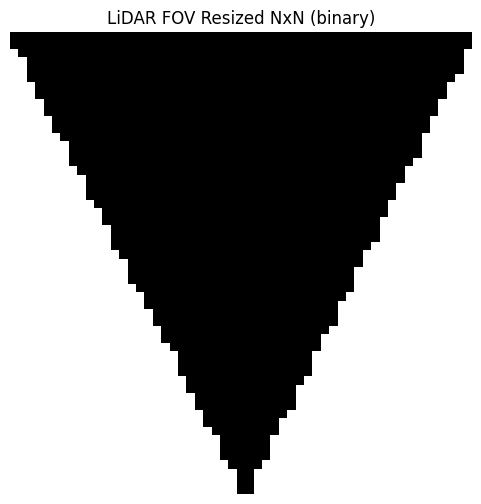

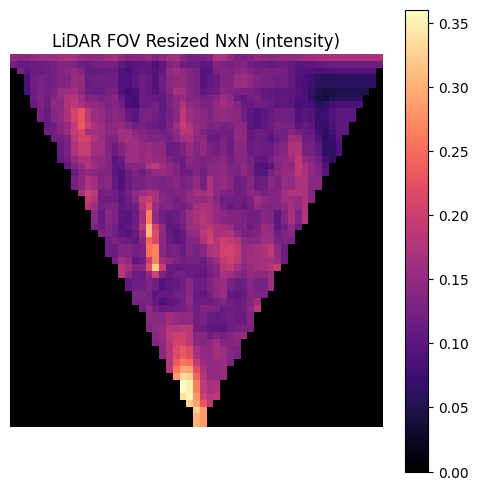

In [37]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# ======================================================
# 0) Paths
# ======================================================
lidar_pt  = "/home/draiman/Desktop/Datasets_nuscenes/validation/lidar/01a7d01c014f406f87b8fe11976c3d0a.pt"
camera_pt = "/home/draiman/Desktop/Datasets_nuscenes/validation/resnet/CAM_FRONT/01a7d01c014f406f87b8fe11976c3d0a.pt"

pc_range = [-51.2, -51.2, -5.0, 51.2, 51.2, 3.0]


# ======================================================
# 1) Load LiDAR + CAMERA features
# ======================================================
lidar_blob = torch.load(lidar_pt, map_location="cpu")
cam_blob   = torch.load(camera_pt, map_location="cpu")

lidar_feat = lidar_blob["feat"].squeeze(0)    # [C=256, 90,90]
lidar2img  = cam_blob["lidar2img"]            # 4x4
img_shape  = tuple(cam_blob["img_shape"][0])[:2]

C, H, W = lidar_feat.shape
print("LiDAR BEV:", lidar_feat.shape)


# ======================================================
# 2) Compute BEV grid (x,y)
# ======================================================
x_min, y_min, _, x_max, y_max, _ = pc_range
dx = (x_max - x_min) / W
dy = (y_max - y_min) / H

xs = np.linspace(x_min + dx/2, x_max - dx/2, W)
ys = np.linspace(y_min + dy/2, y_max - dy/2, H)
xs, ys = np.meshgrid(xs, ys)

zs = np.zeros_like(xs)
pts = np.stack([xs, ys, zs, np.ones_like(xs)], axis=-1).reshape(-1,4)


# ======================================================
# 3) Project into camera
# ======================================================
proj = (lidar2img @ pts.T).T
u = proj[:,0] / (proj[:,2] + 1e-6)
v = proj[:,1] / (proj[:,2] + 1e-6)
z_cam = proj[:,2]

img_h, img_w = img_shape

valid = (
    (u >= 0) & (u < img_w) &
    (v >= 0) & (v < img_h) &
    (z_cam > 0)
)

valid_mask = valid.reshape(H, W)
print("Valid mask TRUE count:", valid_mask.sum())


# ======================================================
# 4) Apply mask
# ======================================================
# Make sure valid_mask is torch tensor [1,H,W]
if isinstance(valid_mask, np.ndarray):
    valid_mask_t = torch.from_numpy(valid_mask).float().unsqueeze(0)
elif isinstance(valid_mask, torch.Tensor):
    valid_mask_t = valid_mask.float().unsqueeze(0)
else:
    raise TypeError(f"Unexpected valid_mask type: {type(valid_mask)}")



lidar_visible = lidar_feat * valid_mask_t    # [C,H,W]


# ======================================================
# 5) Extract cone shape (no rectangular crop)
# ======================================================
row_has = valid_mask.any(axis=1)
col_has = valid_mask.any(axis=0)

row_min, row_max = np.where(row_has)[0][[0,-1]]
col_min, col_max = np.where(col_has)[0][[0,-1]]

lidar_cone = lidar_visible[:, row_min:row_max+1, col_min:col_max+1]

print("Cone shape BEFORE resizing:", lidar_cone.shape)
# example expected ~[256, 60, 120]


# ======================================================
# 6) Make it square NxN where N = widest cone row
# ======================================================
cone_mask = valid_mask[row_min:row_max+1, col_min:col_max+1]
widths = cone_mask.sum(axis=1)
N = int(widths.max())

print("Widest row =", N)

# Resize only if spatial dims >= 2
Hc, Wc = cone_mask.shape
if Hc >= 2 and Wc >= 2:
    # lidar_cone_resized = torch.nn.functional.interpolate(
    #     lidar_cone.unsqueeze(0), 
    #     size=(N, N),
    #     mode="bilinear",
    #     align_corners=True
    # ).squeeze(0)

    lidar_cone_resized = torch.nn.functional.interpolate(
    lidar_cone.unsqueeze(0), 
    size=(N, N),
    mode="nearest"
    ).squeeze(0)


else:
    lidar_cone_resized = lidar_cone  # fallback (should not happen now)


print("Final NxN FOV BEV:", lidar_cone_resized.shape)


# ======================================================
# 7) Visualize
# ======================================================
plt.figure(figsize=(6,6))
plt.title("LiDAR FOV Resized NxN (binary)")
mask_show = (lidar_cone_resized.sum(0).numpy() != 0)
plt.imshow(1-mask_show, cmap="gray", origin="lower")
plt.axis("off")
plt.show()

plt.figure(figsize=(6,6))
plt.title("LiDAR FOV Resized NxN (intensity)")
plt.imshow(lidar_cone_resized.mean(0).numpy(), cmap="magma", origin="lower")
plt.colorbar()
plt.axis("off")
plt.show()


Input LiDAR cone: torch.Size([256, 55, 55])
LiDAR POLAR shape: torch.Size([256, 80, 180])


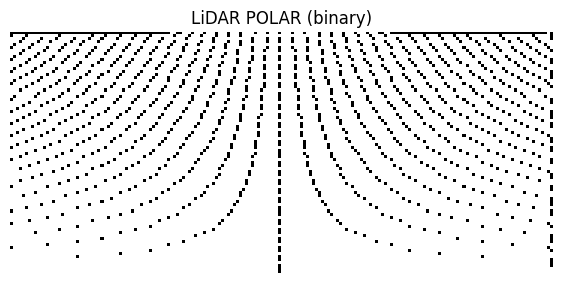

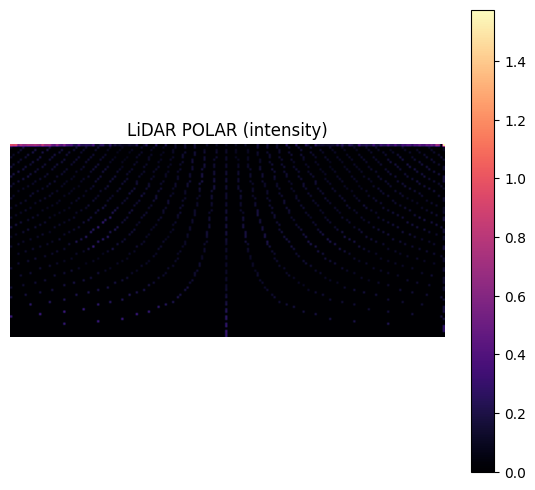

In [39]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------
# CONFIG — Set your shared polar grid
# ------------------------------------------------------
N_r = 80        # number of radial bins
N_theta = 180   # number of angular bins
r_min = 0.0
r_max = 50.0

thetas = np.linspace(-np.pi/4, np.pi/4, N_theta)   # front FOV ±45°
rs = np.linspace(r_min, r_max, N_r)

# ------------------------------------------------------
# 1) Your NxN LiDAR cone (55×55)
# ------------------------------------------------------
lidar_cone = lidar_cone_resized    # shape [256, 55, 55]
C, Hc, Wc = lidar_cone.shape

print("Input LiDAR cone:", lidar_cone.shape)

# ------------------------------------------------------
# 2) Build (x,y) coords for the NxN cone
#    We assume:
#      x = forward (rows)
#      y = left-right (cols)
# ------------------------------------------------------
# Scale NxN grid back to metric (0→50m range)
xs = np.linspace(0, r_max, Hc)        # forward range
ys = np.linspace(-r_max, r_max, Wc)   # lateral range
Xg, Yg = np.meshgrid(xs, ys, indexing='ij')   # [Hc,Wc]

# Convert to polar
R = np.sqrt(Xg**2 + Yg**2)
Theta = np.arctan2(Yg, Xg)

# ------------------------------------------------------
# 3) Digitize into polar bins
# ------------------------------------------------------
r_idx = np.digitize(R, rs) - 1
theta_idx = np.digitize(Theta, thetas) - 1

valid = (
    (r_idx >= 0) & (r_idx < N_r) &
    (theta_idx >= 0) & (theta_idx < N_theta)
)

flat_valid = np.where(valid.reshape(-1))[0]

r_valid = r_idx.reshape(-1)[flat_valid]
t_valid = theta_idx.reshape(-1)[flat_valid]

lidar_flat = lidar_cone.reshape(C, -1)

# ------------------------------------------------------
# 4) Accumulate into polar grid
# ------------------------------------------------------
lidar_polar = np.zeros((C, N_r, N_theta), dtype=np.float32)

for c in range(C):
    np.add.at(lidar_polar[c], (r_valid, t_valid), lidar_flat[c, flat_valid])

lidar_polar = torch.tensor(lidar_polar)

print("LiDAR POLAR shape:", lidar_polar.shape)

# ------------------------------------------------------
# 5) Visualize
# ------------------------------------------------------
plt.figure(figsize=(7,6))
plt.title("LiDAR POLAR (binary)")
mask = (lidar_polar.sum(0).numpy() != 0)
plt.imshow(1-mask, cmap='gray', origin='lower')
plt.axis("off")
plt.show()

plt.figure(figsize=(7,6))
plt.title("LiDAR POLAR (intensity)")
plt.imshow(lidar_polar.mean(0).numpy(), cmap='magma', origin='lower')
plt.colorbar()
plt.axis("off")
plt.show()


In [33]:
print(lidar_polar.mean(), lidar_polar.max())

tensor(0.0148) tensor(17.3632)


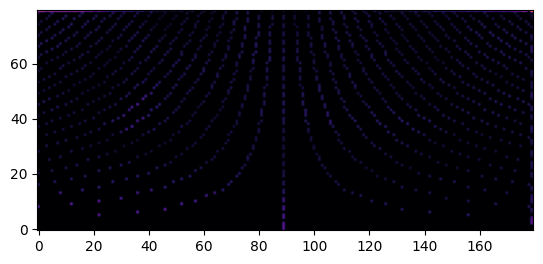

In [ ]:
vis = np.log1p(lidar_polar.mean(0).numpy())
plt.imshow(vis, cmap="magma", origin="lower")




In [40]:
print(lidar_polar.mean(), lidar_polar.max())


tensor(0.0147) tensor(16.1357)


torch.Size([256, 125, 200])
Widest part width = 92 cells
Row index (X direction) = 59
Non-empty rows in X: (13, 108)


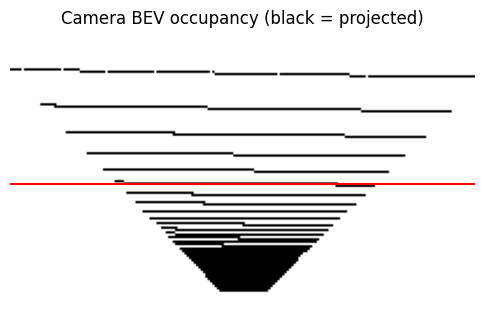

In [46]:
sample = dataset[0]          # or any idx
cam_bev = sample["cam_bev"]  # [C, H, W]  e.g. [256, 125, 200]
print(cam_bev.shape)


# Find which cells are “occupied” by camera projection
import torch
import matplotlib.pyplot as plt

C, H, W = cam_bev.shape

# any non-zero feature across channels → occupied cell
mask = (cam_bev.abs().sum(0) != 0)      # [H, W] bool


# Find the widest row in BEV (front-back = H)
row_counts = mask.sum(dim=1)            # [H], number of occupied cells per row
max_width, max_row = row_counts.max(dim=0)

print(f"Widest part width = {int(max_width)} cells")
print(f"Row index (X direction) = {int(max_row)}")


# (Optional) See start/end of the cone in X

rows_with_any = torch.nonzero(row_counts > 0, as_tuple=False).squeeze(1)
x_min_row = int(rows_with_any[0])
x_max_row = int(rows_with_any[-1])
print(f"Non-empty rows in X: ({x_min_row}, {x_max_row})")


plt.figure(figsize=(6,6))
plt.title("Camera BEV occupancy (black = projected)")
plt.imshow(~mask.numpy(), cmap="gray", origin="lower")
plt.axhline(max_row, color="red")  # widest row
plt.axis("off")
plt.show()




Camera BEV: torch.Size([256, 125, 200])
Cell size (m): 0.4 0.25
WIDEST physical width = 23.00 m at row 59


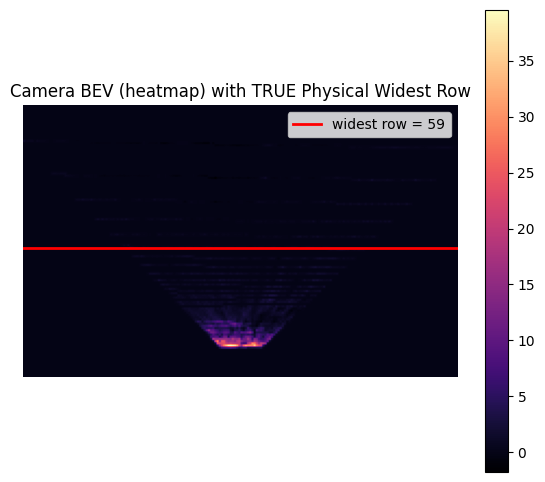

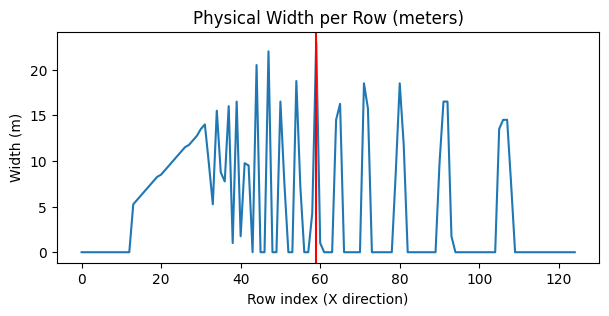

In [57]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------------
# 1) Load a camera BEV sample
# -------------------------------------------------------------
sample = dataset[0]        # or any index
cam_bev = sample["cam_bev"]   # [C, H, W]
print("Camera BEV:", cam_bev.shape)

C, H, W = cam_bev.shape

# -------------------------------------------------------------
# 2) Create occupancy mask (any non-zero feature)
# -------------------------------------------------------------
mask = (cam_bev.abs().sum(0) != 0)   # [H, W] boolean mask

# -------------------------------------------------------------
# 3) Compute real-world grid cell sizes (meters per cell)
# -------------------------------------------------------------
# These come from your BEVSpec
cell_x = bev_spec.cell_x   # meters per row
cell_y = bev_spec.cell_y   # meters per column

print("Cell size (m):", cell_x, cell_y)

# -------------------------------------------------------------
# 4) Compute physical width per row (meters)
# -------------------------------------------------------------
row_width_m = np.zeros(H)

for r in range(H):
    cols = torch.where(mask[r])[0]
    if len(cols) > 0:
        col_min = cols.min().item()
        col_max = cols.max().item()
        row_width_m[r] = (col_max - col_min + 1) * cell_y  # width in meters
    else:
        row_width_m[r] = 0.0

# Find the widest physical row
widest_row = int(np.argmax(row_width_m))
widest_width_m = row_width_m[widest_row]

print(f"WIDEST physical width = {widest_width_m:.2f} m at row {widest_row}")

# -------------------------------------------------------------
# 5) Convert BEV features into a smooth heatmap
# -------------------------------------------------------------
heat = cam_bev.mean(0).cpu().numpy()   # [H, W] smooth heatmap

plt.figure(figsize=(7,6))
plt.title("Camera BEV (heatmap) with TRUE Physical Widest Row")
plt.imshow(heat, cmap="magma", origin="lower")
plt.axhline(widest_row, color="red", linewidth=2, label=f"widest row = {widest_row}")
plt.colorbar()
plt.legend()
plt.axis("off")
plt.show()

# -------------------------------------------------------------
# 6) Plot physical width per row
# -------------------------------------------------------------
plt.figure(figsize=(7,3))
plt.plot(row_width_m)
plt.axvline(widest_row, color='red')
plt.title("Physical Width per Row (meters)")
plt.xlabel("Row index (X direction)")
plt.ylabel("Width (m)")
plt.show()


Raw camera feature shape: torch.Size([2048, 29, 50])


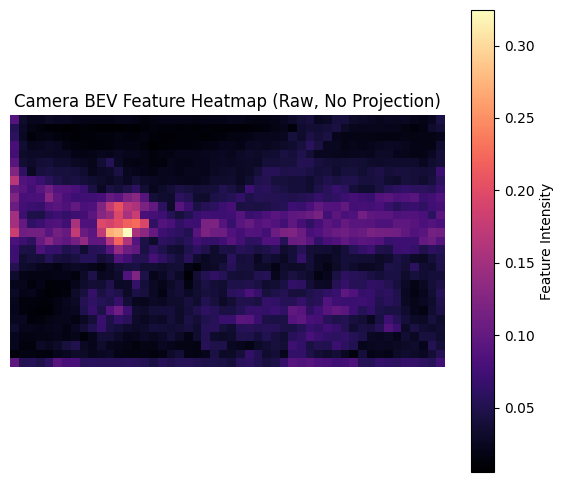

In [54]:
# Jupyter Cell — Show Camera Feature Heatmap (Raw BEV Features)


import torch
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# Load camera BEV (from your dataset)
# ---------------------------------------------------------
# sample = dataset[0]              # or any index you want
# cam_bev = sample["cam_bev"]      # shape [C, H, W]

# C, H, W = cam_bev.shape
# print("Camera BEV shape:", cam_bev.shape)

# # ---------------------------------------------------------
# # Convert to a heatmap (average over channels)
# # ---------------------------------------------------------
# heat = cam_bev.mean(0).cpu().numpy()   # [H, W]



camera_pt = "/home/draiman/Desktop/Datasets_nuscenes/validation/resnet/CAM_FRONT/01a7d01c014f406f87b8fe11976c3d0a.pt"
blob = torch.load(camera_pt, map_location="cpu")

cam_feat = blob["feat"]     # shape [C, Hf, Wf]
if cam_feat.ndim == 3:
    cam_feat = cam_feat.unsqueeze(0)   # [1,C,Hf,Wf]

cam_feat = cam_feat.squeeze(0)         # [C,Hf,Wf]
print("Raw camera feature shape:", cam_feat.shape)

# ---------------------------------------------------------
# Convert to a heatmap (average over channels)
# ---------------------------------------------------------
heat = cam_feat.mean(0).cpu().numpy()   # [H, W]

# ---------------------------------------------------------
# Plot smooth heatmap
# ---------------------------------------------------------
plt.figure(figsize=(7,6))
plt.title("Camera BEV Feature Heatmap (Raw, No Projection)")
plt.imshow(heat, cmap="magma", origin="lower")
plt.colorbar(label="Feature Intensity")
plt.axis("off")
plt.show()


Raw feature map: torch.Size([2048, 29, 50])
Stride (u,v): 32.0 32.0
BEV grid: 125 x 200
Final camera BEV: torch.Size([2048, 125, 200])
WIDEST REAL-WORLD WIDTH = 19.50 m at row 52


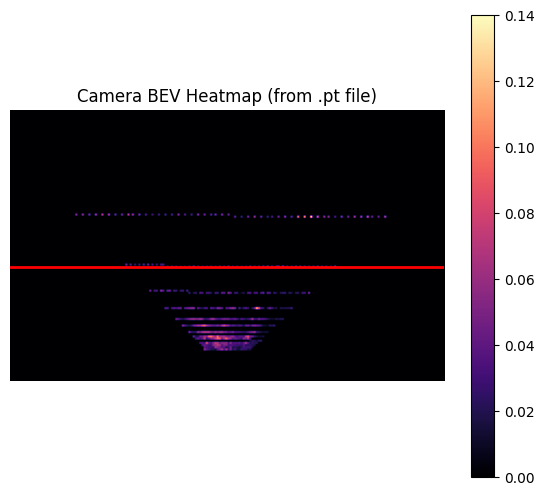

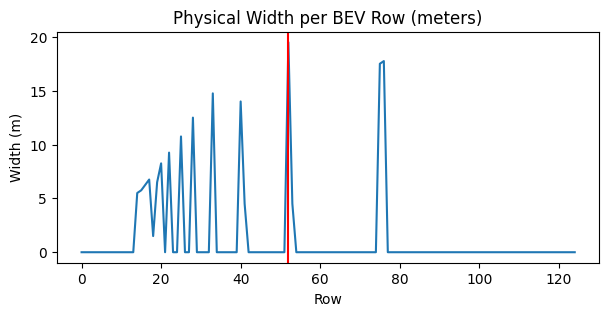

In [56]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------------
# USER PATHS
# -------------------------------------------------------------
camera_pt = "/home/draiman/Desktop/Datasets_nuscenes/validation/resnet/CAM_FRONT/01a7d01c014f406f87b8fe11976c3d0a.pt"
metadata_csv = "/home/draiman/Desktop/Datasets_nuscenes/nuscenes_metadata.csv"
camera_name = "CAM_FRONT"

# Load metadata once
metadata_df = pd.read_csv(metadata_csv)

# Token from filename
token = camera_pt.split("/")[-1].replace(".pt", "")

# -------------------------------------------------------------
# LOAD RAW CAMERA FEATURES FROM .pt
# -------------------------------------------------------------
blob = torch.load(camera_pt, map_location="cpu")

cam_feat = blob["feat"]    # [C,Hf,Wf]
if cam_feat.ndim == 3:
    cam_feat = cam_feat.unsqueeze(0)  # [1,C,Hf,Wf]

cam_feat = cam_feat.squeeze(0)        # [C,Hf,Wf]
print("Raw feature map:", cam_feat.shape)

# Image shape
img_h, img_w, _ = blob["img_shape"][0]

# Feature map size
C, Hf, Wf = cam_feat.shape

# Dynamic stride
stride_u = img_w / Wf
stride_v = img_h / Hf

print("Stride (u,v):", stride_u, stride_v)

# -------------------------------------------------------------
# LOAD CAMERA CALIBRATION
# -------------------------------------------------------------
row = metadata_df.query(
    f"sample_token == '{token}' and camera_name == '{camera_name}'"
).iloc[0]

# Intrinsic matrix
K = np.array(row["cam_intrinsic"].split(";"), float).reshape(3,3)

# Rotation matrix
from pyquaternion import Quaternion
R = Quaternion([float(x) for x in row["sensor2ego_rotation"].split(";")]).rotation_matrix

# Translation
T = np.array(row["sensor2ego_translation"].split(";"), float)

# -------------------------------------------------------------
# SET YOUR BEV GRID
# -------------------------------------------------------------
x_min, x_max = 0.0, 50.0
y_min, y_max = -25.0, 25.0
cell_x, cell_y = 0.4, 0.25

H_bev = int(np.ceil((x_max - x_min)/cell_x))
W_bev = int(np.ceil((y_max - y_min)/cell_y))

print("BEV grid:", H_bev, "x", W_bev)

# -------------------------------------------------------------
# PROJECT CAMERA FEATURES INTO BEV
# -------------------------------------------------------------
# Pixel centers
i = (torch.arange(Hf).float() + 0.5) * stride_v
j = (torch.arange(Wf).float() + 0.5) * stride_u
V, U = torch.meshgrid(i, j, indexing='ij')

uv1 = np.stack([U.reshape(-1).numpy(), V.reshape(-1).numpy(), np.ones(Hf*Wf)], axis=0)

# Rays
K_inv = np.linalg.inv(K)
rays_cam = K_inv @ uv1
rays_cam[1,:] *= -1

rays_ego = R @ rays_cam
dir_z = rays_ego[2,:]
cam_z = T[2]

# Intersection with ground
s = -cam_z / (dir_z + 1e-12)
Xg = T[0] + s * rays_ego[0,:]
Yg = T[1] + s * rays_ego[1,:]

# BEV indices
ix = ((Xg - x_min) / cell_x).astype(int)
iy = ((Yg - y_min) / cell_y).astype(int)

valid = (ix >= 0) & (ix < H_bev) & (iy >= 0) & (iy < W_bev) & (s > 0)

# Create empty BEV
cam_bev = torch.zeros((C, H_bev, W_bev))

flat = cam_feat.reshape(C, -1)
valid_idx = np.where(valid)[0]

ixv = torch.tensor(ix[valid_idx]).long()
iyv = torch.tensor(iy[valid_idx]).long()

for c in range(C):
    cam_bev[c, ixv, iyv] = flat[c, valid_idx]

print("Final camera BEV:", cam_bev.shape)

# -------------------------------------------------------------
# COMPUTE OCCUPANCY MASK
# -------------------------------------------------------------
mask = (cam_bev.abs().sum(0) != 0)  # [H,W]

# -------------------------------------------------------------
# COMPUTE REAL-WORLD WIDTH PER ROW
# -------------------------------------------------------------
row_width_m = np.zeros(H_bev)

for r in range(H_bev):
    cols = torch.where(mask[r])[0]
    if len(cols) > 0:
        row_width_m[r] = (cols.max()-cols.min()+1)*cell_y

widest_row = int(np.argmax(row_width_m))
widest_width_m = row_width_m[widest_row]

print(f"WIDEST REAL-WORLD WIDTH = {widest_width_m:.2f} m at row {widest_row}")

# -------------------------------------------------------------
# VISUALIZE HEATMAP
# -------------------------------------------------------------
heat = cam_bev.mean(0).numpy()

plt.figure(figsize=(7,6))
plt.title("Camera BEV Heatmap (from .pt file)")
plt.imshow(heat, cmap="magma", origin="lower")
plt.axhline(widest_row, color="red", linewidth=2)
plt.colorbar()
plt.axis("off")
plt.show()

# -------------------------------------------------------------
# WIDTH vs ROW PLOT
# -------------------------------------------------------------
plt.figure(figsize=(7,3))
plt.plot(row_width_m)
plt.axvline(widest_row, color='red')
plt.title("Physical Width per BEV Row (meters)")
plt.xlabel("Row")
plt.ylabel("Width (m)")
plt.show()


1) RAW camera feature filled cells = 1450
BEV grid = 125 x 200
2) UNSMOOTHED BEV filled cells = 492
3) SMOOTHED BEV filled cells = 1793


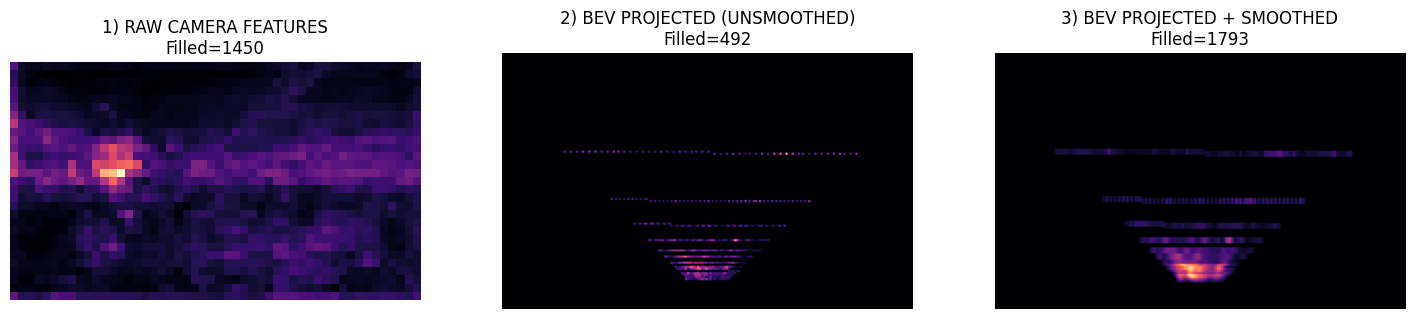

In [58]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pyquaternion import Quaternion

# -------------------------------------------------------------
# USER INPUTS
# -------------------------------------------------------------
camera_pt = "/home/draiman/Desktop/Datasets_nuscenes/validation/resnet/CAM_FRONT/01a7d01c014f406f87b8fe11976c3d0a.pt"
metadata_csv = "/home/draiman/Desktop/Datasets_nuscenes/nuscenes_metadata.csv"
camera_name = "CAM_FRONT"

# BEV grid definition
x_min, x_max = 0.0, 50.0
y_min, y_max = -25.0, 25.0
cell_x, cell_y = 0.4, 0.25

# -------------------------------------------------------------
# LOAD RAW CAMERA FEATURES (.pt)
# -------------------------------------------------------------
blob = torch.load(camera_pt, map_location="cpu")
cam_feat = blob["feat"]                      # [C,Hf,Wf]
if cam_feat.ndim == 3:
    cam_feat = cam_feat.unsqueeze(0)
cam_feat = cam_feat.squeeze(0)

C, Hf, Wf = cam_feat.shape
raw_heat = cam_feat.mean(0).numpy()          # HxW

img_h, img_w, _ = blob["img_shape"][0]

# -------------------------------------------------------------
# COUNT #1 — raw camera feature non-zero cells
# -------------------------------------------------------------
raw_filled = int((raw_heat != 0).sum())
print(f"1) RAW camera feature filled cells = {raw_filled}")

# -------------------------------------------------------------
# LOAD METADATA CALIBRATION
# -------------------------------------------------------------
df = pd.read_csv(metadata_csv)
token = camera_pt.split("/")[-1].replace(".pt", "")
row = df.query(f"sample_token == '{token}' and camera_name == '{camera_name}'").iloc[0]

# intrinsics
K = np.array(row["cam_intrinsic"].split(";"), float).reshape(3,3)
K_inv = np.linalg.inv(K)

# extrinsics
R = Quaternion([float(x) for x in row["sensor2ego_rotation"].split(";")]).rotation_matrix
T = np.array(row["sensor2ego_translation"].split(";"), float)

# -------------------------------------------------------------
# BUILD BEV GRID SIZE
# -------------------------------------------------------------
H_bev = int(np.ceil((x_max - x_min)/cell_x))
W_bev = int(np.ceil((y_max - y_min)/cell_y))
print(f"BEV grid = {H_bev} x {W_bev}")

# -------------------------------------------------------------
# PROJECT raw camera features into BEV (no smoothing)
# -------------------------------------------------------------
stride_u = img_w / Wf
stride_v = img_h / Hf

i = (torch.arange(Hf).float() + 0.5) * stride_v
j = (torch.arange(Wf).float() + 0.5) * stride_u
V, U = torch.meshgrid(i, j, indexing='ij')

uv1 = np.stack([U.reshape(-1).numpy(),
                V.reshape(-1).numpy(),
                np.ones(Hf*Wf)], axis=0)

# rays in camera
rays_cam = K_inv @ uv1
rays_cam[1, :] *= -1

# rays in ego
rays_ego = R @ rays_cam

# intersection with ground
cam_z = T[2]
s = -cam_z / (rays_ego[2,:] + 1e-12)
Xg = T[0] + s * rays_ego[0,:]
Yg = T[1] + s * rays_ego[1,:]

# BEV indices
ix = ((Xg - x_min) / cell_x).astype(int)
iy = ((Yg - y_min) / cell_y).astype(int)

valid = (ix >= 0) & (ix < H_bev) & (iy >= 0) & (iy < W_bev) & (s > 0)
valid_idx = np.where(valid)[0]

cam_bev = torch.zeros((C, H_bev, W_bev))
flat = cam_feat.reshape(C, -1)

ixv = torch.tensor(ix[valid_idx]).long()
iyv = torch.tensor(iy[valid_idx]).long()

for c in range(C):
    cam_bev[c, ixv, iyv] = flat[c, valid_idx]

unsmoothed_heat = cam_bev.mean(0).numpy()

# COUNT #2 — BEV projection (unsmoothed)
unsmoothed_filled = int((unsmoothed_heat != 0).sum())
print(f"2) UNSMOOTHED BEV filled cells = {unsmoothed_filled}")

# -------------------------------------------------------------
# SMOOTHING — 3x3 average filter
# -------------------------------------------------------------
kernel = np.ones((3,3))/9
from scipy.signal import convolve2d
smoothed_heat = convolve2d(unsmoothed_heat, kernel, mode="same")

# COUNT #3 — smoothed BEV
smoothed_filled = int((smoothed_heat > 1e-6).sum())
print(f"3) SMOOTHED BEV filled cells = {smoothed_filled}")

# -------------------------------------------------------------
# PLOT ALL 3 IN ONE CELL
# -------------------------------------------------------------
fig, ax = plt.subplots(1,3, figsize=(18,6))

ax[0].imshow(raw_heat, cmap="magma", origin="lower")
ax[0].set_title(f"1) RAW CAMERA FEATURES\nFilled={raw_filled}")
ax[0].axis("off")

ax[1].imshow(unsmoothed_heat, cmap="magma", origin="lower")
ax[1].set_title(f"2) BEV PROJECTED (UNSMOOTHED)\nFilled={unsmoothed_filled}")
ax[1].axis("off")

ax[2].imshow(smoothed_heat, cmap="magma", origin="lower")
ax[2].set_title(f"3) BEV PROJECTED + SMOOTHED\nFilled={smoothed_filled}")
ax[2].axis("off")

plt.show()


Dataset camera BEV: torch.Size([256, 125, 200])
2) dataset cam_bev filled cells = 2402
1) raw camera feature filled cells = 1450
3) BEV occupancy mask filled cells = 2402


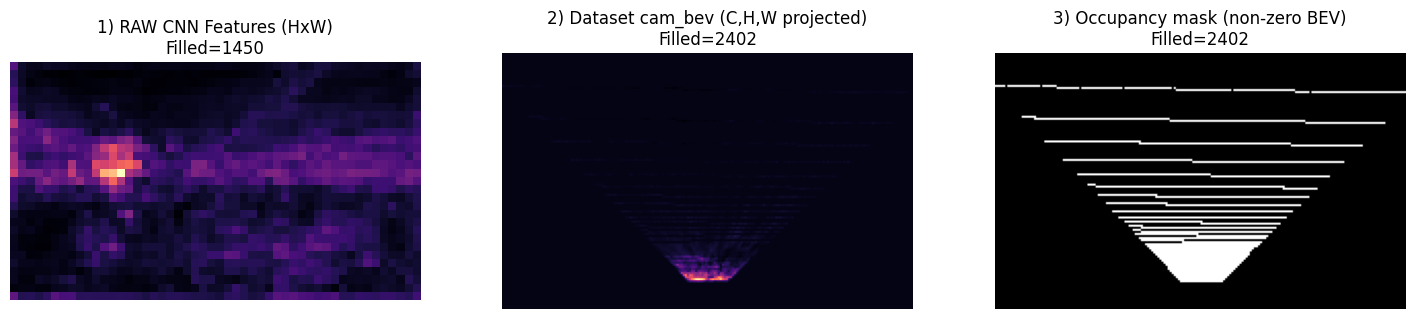

In [59]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------------
# LOAD camera BEV from your dataset
# -------------------------------------------------------------
sample = dataset[0]            # (DO NOT replace this)
cam_bev = sample["cam_bev"]    # [C, H, W]
print("Dataset camera BEV:", cam_bev.shape)

C_bev, H_bev, W_bev = cam_bev.shape
bev_heat = cam_bev.mean(0).numpy()        # for visualization

# Occupancy count for BEV
bev_filled = int((bev_heat != 0).sum())
print(f"2) dataset cam_bev filled cells = {bev_filled}")

# -------------------------------------------------------------
# LOAD raw camera CNN features directly from .pt
# -------------------------------------------------------------
camera_pt = "/home/draiman/Desktop/Datasets_nuscenes/validation/resnet/CAM_FRONT/01a7d01c014f406f87b8fe11976c3d0a.pt"
blob = torch.load(camera_pt, map_location="cpu")

cam_feat = blob["feat"]   # [C, Hf, Wf]
if cam_feat.ndim == 3:
    cam_feat = cam_feat.unsqueeze(0)
cam_feat = cam_feat.squeeze(0)

C_raw, H_raw, W_raw = cam_feat.shape
raw_heat = cam_feat.mean(0).numpy()

raw_filled = int((raw_heat != 0).sum())
print(f"1) raw camera feature filled cells = {raw_filled}")

# -------------------------------------------------------------
# 3) Occupancy mask from dataset BEV
# -------------------------------------------------------------
mask = (cam_bev.abs().sum(0) != 0).numpy()   # boolean mask
occ_filled = int(mask.sum())
print(f"3) BEV occupancy mask filled cells = {occ_filled}")

# -------------------------------------------------------------
# PLOT ALL 3 IN ONE CELL
# -------------------------------------------------------------
fig, ax = plt.subplots(1,3, figsize=(18,6))

# RAW CNN FEATURE MAP
ax[0].imshow(raw_heat, cmap="magma", origin="lower")
ax[0].set_title(f"1) RAW CNN Features (HxW)\nFilled={raw_filled}")
ax[0].axis("off")

# BEV FROM DATASET
ax[1].imshow(bev_heat, cmap="magma", origin="lower")
ax[1].set_title(f"2) Dataset cam_bev (C,H,W projected)\nFilled={bev_filled}")
ax[1].axis("off")

# OCCUPANCY MASK
ax[2].imshow(mask, cmap="gray", origin="lower")
ax[2].set_title(f"3) Occupancy mask (non-zero BEV)\nFilled={occ_filled}")
ax[2].axis("off")

plt.show()
